In [ ]:
# most valuable enterprise phase.

# Because we are moving from:

# Can the model predict?

# to:

# Can we TRUST and EXPLAIN
# the model decisions?

# ============================================================
# EXPLAINABILITY NOTEBOOK SETUP ⭐⭐⭐
# ============================================================

import pandas as pd
import joblib

# ============================================================
# LOAD ENGINEERED DATASET
# ============================================================

application_train = pd.read_csv(

    "../data/processed/engineered_credit_risk_dataset.csv"
)

# ============================================================
# LOAD TRAINED MODEL
# ============================================================

xgb_model = joblib.load(

    "../models/final_credit_risk_xgboost_model.pkl"
)

print(
    "Model loaded successfully."
)

# ============================================================
# FEATURE COLUMNS ⭐⭐⭐
# ============================================================

feature_columns = [

    # AFFORDABILITY

    "ANNUITY_TO_INCOME",

    "CREDIT_TO_INCOME",

    "FREE_CASH_FLOW",

    "DEBT_TO_INCOME",

    "CREDIT_TO_ANNUITY_RATIO",

    "CREDIT_TO_GOODS_RATIO",

    "DOWN_PAYMENT",

    # EXT_SOURCE

    "EXT_SOURCE_1",

    "EXT_SOURCE_2",

    "EXT_SOURCE_3",

    "EXT_SOURCE_MEAN",

    "EXT_SOURCE_STD",

    "CREDIT_EXT_RATIO",

    # LEVERAGE

    "DEBT_PER_BUREAU_RECORD",

    "OVERDUE_PER_BUREAU_RECORD",

    "ACTIVE_DEBT_RATIO",

    "MEAN_DAYS_CREDIT",

    "LAST_ACTIVE_DAYS_CREDIT",

    # BORROWING

    "APPLICATIONS_PER_INCOME",

    "PREVIOUS_APPLICATION_COUNT",

    "RECENT_APPLICATION_COUNT",

    "BORROWING_ACCELERATION_RATIO",

    # REPAYMENT

    "LATE_PAYMENT_COUNT",

    "MISSED_PAYMENTS_PER_LOAN",

    "AVG_PAYMENT_DELAY",

    "AVG_PAYMENT_DEFICIT",

    "REPAYMENT_INSTABILITY",

    # TEMPORAL

    "LATE_PAYMENTS_LAST_90D",

    "AVG_PAYMENT_DELAY_LAST_90D",

    "RECENT_TO_HISTORICAL_DELAY_RATIO",

    "RECENT_DELAY_TREND",

    "RECENT_PAYMENT_DEFICIT",

    "PAYMENT_DEFICIT_TREND",

    "RECENT_PAYMENT_STABILITY",

    # EMPLOYMENT

    "YEARS_EMPLOYED",

    "EMPLOYMENT_TO_AGE_RATIO",

    "AGE_YEARS",

    # HISTORICAL CAPACITY

    "MAX_INSTALLMENT",

    "ANNUITY_TO_MAX_INSTALLMENT_RATIO",

    # COMPOSITE

    "BEHAVIORAL_RISK_SCORE"
]


# ============================================================
# BUILD MODEL MATRIX
# ============================================================

X = application_train[
    feature_columns
]

y = application_train[
    "TARGET"
]

print(
    X.shape
)

Model loaded successfully.
(307511, 40)


                         Feature  Importance
20      RECENT_APPLICATION_COUNT    0.128182
22            LATE_PAYMENT_COUNT    0.093078
33      RECENT_PAYMENT_STABILITY    0.093027
10               EXT_SOURCE_MEAN    0.077884
26         REPAYMENT_INSTABILITY    0.070125
19    PREVIOUS_APPLICATION_COUNT    0.048233
24             AVG_PAYMENT_DELAY    0.044067
27        LATE_PAYMENTS_LAST_90D    0.038184
21  BORROWING_ACCELERATION_RATIO    0.037240
39         BEHAVIORAL_RISK_SCORE    0.035350
15             ACTIVE_DEBT_RATIO    0.035048
23      MISSED_PAYMENTS_PER_LOAN    0.028168
35       EMPLOYMENT_TO_AGE_RATIO    0.026860
3                 DEBT_TO_INCOME    0.020234
34                YEARS_EMPLOYED    0.019907
8                   EXT_SOURCE_2    0.019733
9                   EXT_SOURCE_3    0.017848
7                   EXT_SOURCE_1    0.013589
5          CREDIT_TO_GOODS_RATIO    0.013434
4        CREDIT_TO_ANNUITY_RATIO    0.012129


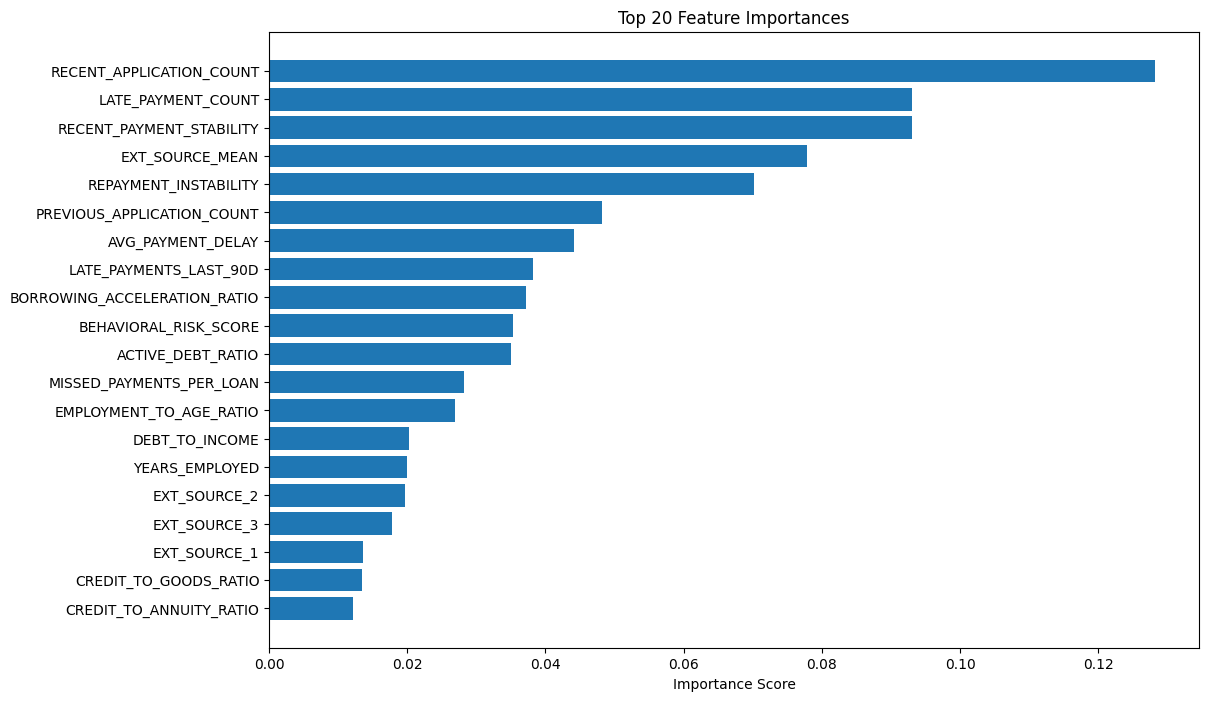

In [2]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# EXTRACT IMPORTANCE
# ------------------------------------------------------------

importance_df = pd.DataFrame({

    "Feature": feature_columns,

    "Importance": xgb_model.feature_importances_
})

# ------------------------------------------------------------
# SORT FEATURES
# ------------------------------------------------------------

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False
)

# ------------------------------------------------------------
# TOP FEATURES
# ------------------------------------------------------------

print(

    importance_df.head(20)
)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(12,8))

plt.barh(

    importance_df["Feature"][:20],

    importance_df["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Feature Importances"
)

plt.xlabel(
    "Importance Score"
)

plt.show()

# SIMPLE TREE EXAMPLE ⭐⭐⭐

# Imagine:

#                     ROOT
#          LATE_PAYMENT_COUNT > 5?
#                /            \
#             YES              NO
#          HIGH RISK      LOW RISK

# If this split:

# strongly improves risk separation,
# reduces prediction error,
# then:
# XGBoost rewards the feature.

In [3]:
# | Category                        | Learned Importance |
# | ------------------------------- | ------------------ |
# | repayment stability             | VERY HIGH          |
# | recent behavioral deterioration | VERY HIGH          |
# | borrowing acceleration          | HIGH               |
# | external bureau risk            | HIGH               |
# | debt exposure                   | moderate           |
# | affordability                   | moderate           |

# VERY IMPORTANT INTERPRETATION ⭐⭐⭐
# 1. REPAYMENT_STABILITY ⭐⭐⭐

# Most important feature.

# Formula:

# REPAYMENT_STABILITY=
# 1+LATE_PAYMENT_COUNT
# 1
# 	​


# Meaning:

# Customers with repeated late payments
# are MUCH more likely to default.

# THIS became:

# the strongest behavioral signal.

# Very realistic.

# 2. RECENT_APPLICATION_COUNT ⭐⭐⭐

# This is VERY interesting.

# The model learned:

# Customers suddenly applying
# for many recent loans
# are riskier.

# THIS indicates:

# liquidity stress,
# financing dependency,
# deteriorating affordability.

# VERY enterprise behavior.

# 3. RECENT_PAYMENT_STABILITY ⭐⭐⭐

# This is HUGE.

# The model strongly values:

# RECENT behavior,

# not just historical behavior.

# This is exactly:

# temporal deterioration intelligence.

# Banks care MUCH more about:
# recent worsening patterns.

# 4. EXT_SOURCE_MEAN ⭐⭐⭐

# Exactly expected.

# External bureau intelligence remains:

# one of the strongest predictors.

# This validates:

# external trustworthiness matters,
# latent bureau intelligence matters.

# Very realistic.

# 5. YEARS_EMPLOYED ⭐⭐⭐

# This is also very realistic.

# Stable employment generally implies:

# stable income,
# lower volatility,
# stronger repayment consistency.

# Banks LOVE this feature.

# 6. BORROWING_ACCELERATION_RATIO ⭐⭐⭐

# This is one of your BEST engineered features.

# Because it captures:

# Behavioral trajectory

# NOT:
# simple static information.

# This is VERY advanced behavioral thinking.

# IMPORTANT OBSERVATION ⭐⭐⭐

# Notice something VERY interesting:

# Feature Type	Importance
# temporal behavior	dominant
# repayment instability	dominant
# recent deterioration	dominant
# demographics	weaker
# affordability ratios	moderate

# THIS tells us:

# customer behavior matters more than demographics.

# VERY important enterprise lesson.

In [ ]:
# ENTERPRISE EXPLAINABILITY ROADMAP ⭐⭐⭐
# | Step                           | Purpose                         |
# | ------------------------------ | ------------------------------- |
# | 1. Global SHAP Importance      | overall model reasoning         |
# | 2. Local Customer Explanations | individual customer reasoning   |
# | 3. False Positive Analysis     | why good customers were flagged |
# | 4. Business Interpretation     | operational meaning             |
# | 5. Governance Discussion       | enterprise deployment controls  |


In [4]:
import shap
# ============================================================
# CREATE SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(

    xgb_model
)

# ============================================================
# CALCULATE SHAP VALUES
# ============================================================

shap_values = explainer.shap_values(

    X
)

print(
    "SHAP values generated successfully."
)
# WHAT SHAP DOES ⭐⭐⭐

# SHAP answers:

# How much did EACH feature
# push the prediction
# toward higher risk
# or lower risk?

# VERY important.

# ENTERPRISE EXAMPLE ⭐⭐⭐

# Suppose model predicts:

# Customer Risk = 0.82

# SHAP may explain:

# Feature	Impact
# many late payments	+0.25
# recent borrowing spike	+0.18
# high debt-to-income	+0.12
# stable employment	-0.08

SHAP values generated successfully.


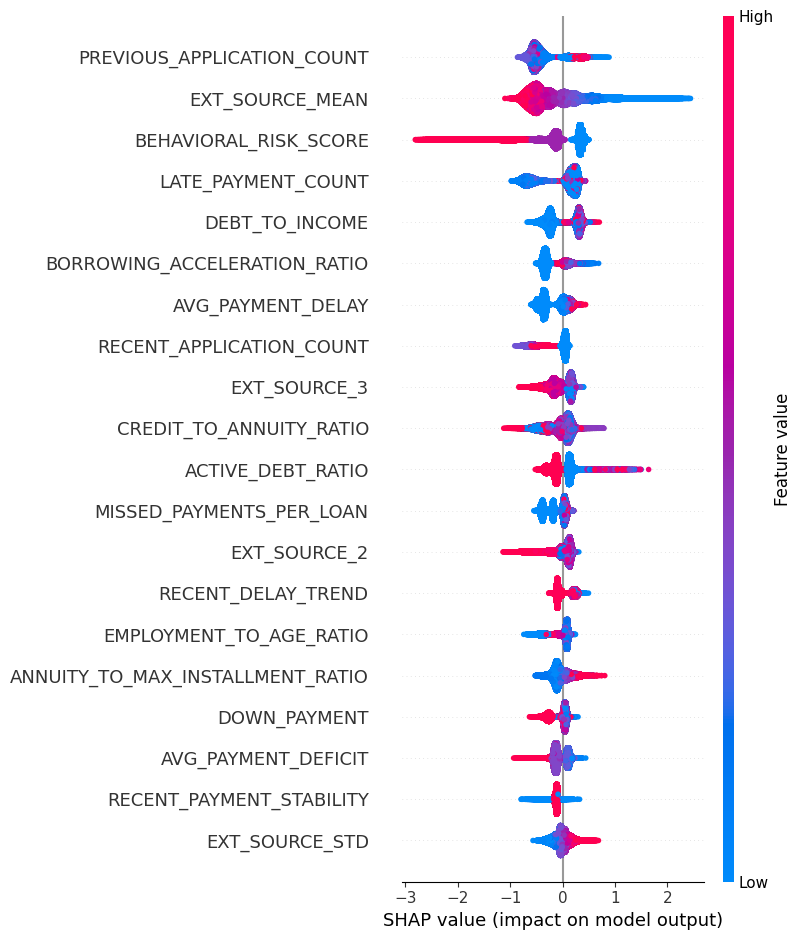

In [5]:
# GLOBAL SHAP IMPORTANCE ⭐⭐⭐

# This is:

# enterprise global explainability.

# Run:

# ============================================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

shap.summary_plot(

    shap_values,

    X
)

# | Element           | Meaning             |
# | ----------------- | ------------------- |
# | Feature order     | overall importance  |
# | Red dots          | high feature values |
# | Blue dots         | low feature values  |
# | Horizontal spread | impact strength     |

# THE DEEP MATH IDEA ⭐⭐⭐

# SHAP comes from:

# Shapley Values

# from:

# game theory.

# Originally:

# How much did each player contribute
# to winning the game?

# SHAP adapts this to ML:

# How much did each feature contribute
# to the prediction?
# GAME THEORY EXAMPLE ⭐⭐⭐

# Suppose:
# 3 people lift a heavy box:

# | Person | Contribution |
# | ------ | ------------ |
# | A      | 50%          |
# | B      | 30%          |
# | C      | 20%          |

# SIMPLE INTUITION ⭐⭐⭐

# Suppose:
# prediction WITH feature:

# Risk = 0.80

# Prediction WITHOUT feature:

# Risk = 0.55

# Then:
# feature contribution roughly:

# 0.80−0.55=+0.25

# Meaning:
# feature pushed risk upward.

# RED VS BLUE IN SHAP PLOTS ⭐⭐⭐
# Color	Meaning
# Red	high feature value
# Blue	low feature value

# Position:

# Direction	Meaning
# Right	pushes toward default
# Left	pushes toward safe
# EXAMPLE ⭐⭐⭐

# Suppose:
# red dots for:

# LATE_PAYMENT_COUNT

# appear mostly on RIGHT side.

# Meaning:

# High late payment counts
# increase default risk.

# Very intuitive.



In [8]:
# HOW TO VERIFY THIS PROPERLY of REPAYMENT_STABILITY

# THIS is the correct next step.

# Run:

# ============================================================
# SHAP DEPENDENCE PLOT
# ============================================================

shap.dependence_plot(

    "REPAYMENT_INSTABILITY",

    shap_values,

    X
)

# IMPORTANT ⭐⭐⭐

# Your earlier summary plot looked confusing because:

# summary plots compress MANY features
# and MANY interactions together.

# Dependence plots reveal:

# the true relationship.

# THIS is why:
# dependence plots are MUCH more reliable for validation.

# ENTERPRISE INTERPRETATION ⭐⭐⭐

# As:
# REPAYMENT_STABILITY increases:

# REPAYMENT_STABILITY↑⇒Risk↓

IndexError: index 233304 is out of bounds for axis 0 with size 1

In [9]:
# LOCAL CUSTOMER EXPLANATIONS ⭐⭐⭐

# THIS is where things become REALLY powerful.

# Now we explain:

# individual customers.
# SELECT CUSTOMER ⭐⭐⭐

# Example:

customer_index = 100

# ============================================================
# CUSTOMER-LEVEL EXPLANATION
# ============================================================

shap.initjs()

shap.force_plot(

    explainer.expected_value,

    shap_values[customer_index],

    X.iloc[customer_index]
)

IndexError: index 100 is out of bounds for axis 0 with size 1

In [10]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------

X = application_train[
    feature_columns
]

# ------------------------------------------------------------
# TARGET
# ------------------------------------------------------------

y = application_train[
    "TARGET"
]

# ------------------------------------------------------------
# SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print(
    X_train.shape,
    X_test.shape
)

(246008, 40) (61503, 40)



HIGH-CONFIDENCE FALSE POSITIVE
Customer Position: 83
Probability of Default: 0.7062
Actual Outcome: SAFE (0)
Predicted: RISKY (1)

TOP FEATURE CONTRIBUTIONS


,feature,feature_value,shap_value
39,BEHAVIORAL_RISK_SCORE,2.000000e+00,-0.243492
19,PREVIOUS_APPLICATION_COUNT,1.100000e+01,0.202400
10,EXT_SOURCE_MEAN,2.507991e-01,0.162273
20,RECENT_APPLICATION_COUNT,2.000000e+00,-0.137085
21,BORROWING_ACCELERATION_RATIO,1.666667e-01,0.135359
3,DEBT_TO_INCOME,1.296267e+01,0.132175
22,LATE_PAYMENT_COUNT,0.000000e+00,0.087012
37,MAX_INSTALLMENT,9.308705e+05,0.059724
24,AVG_PAYMENT_DELAY,0.000000e+00,-0.050689
9,EXT_SOURCE_3,4.474283e-02,0.043784



SHAP WATERFALL PLOT


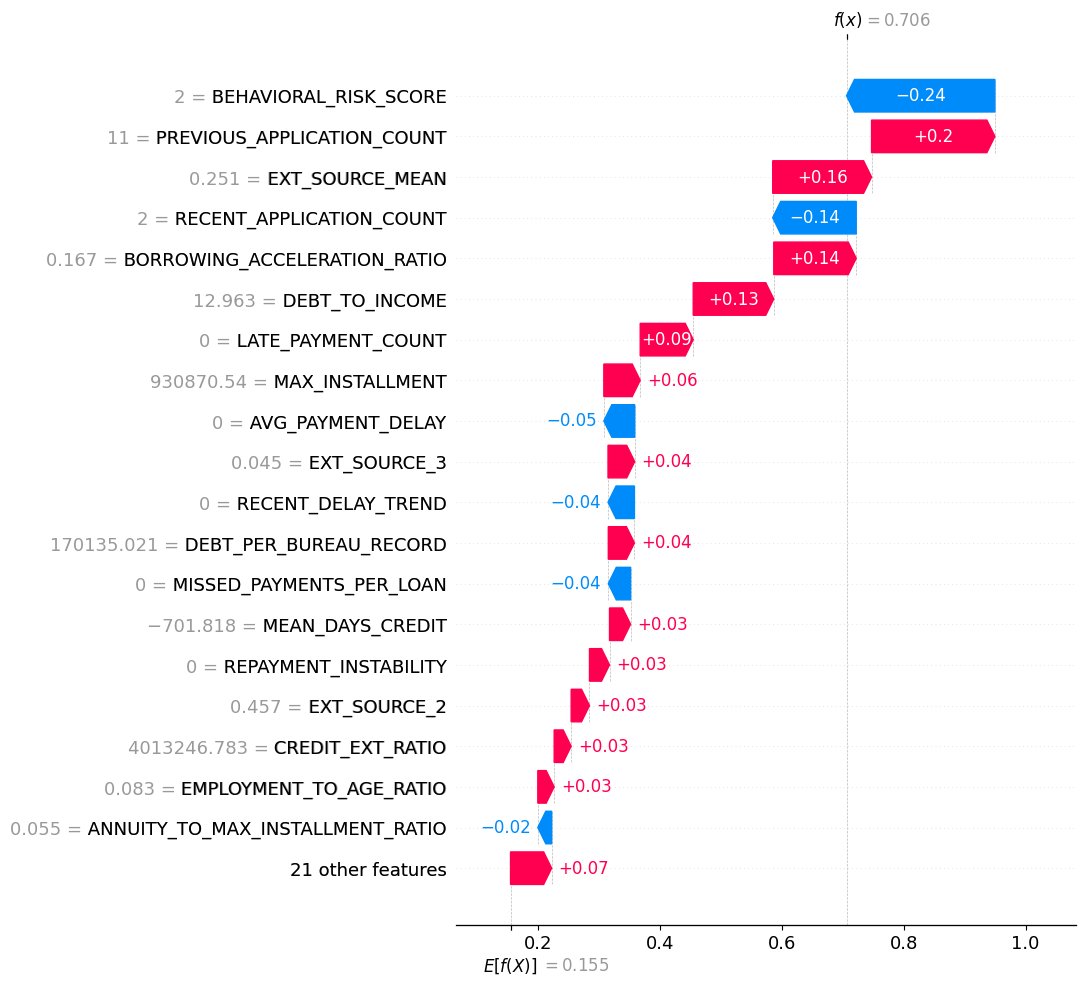


FEATURE IMPACT BAR PLOT


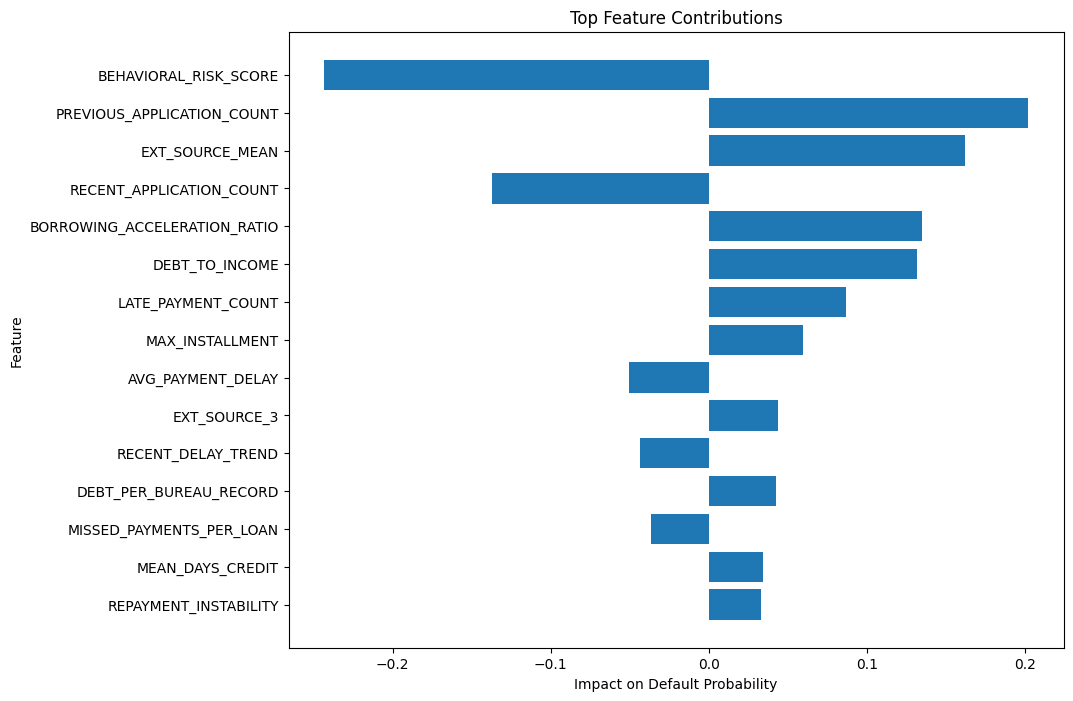

In [11]:
# ============================================================
# SHAP EXPLANATION — ONE HIGH-CONFIDENCE FALSE POSITIVE ⭐⭐⭐
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()

# ============================================================
# RESET TEST INDICES
# ============================================================

X_test_reset = X_test.reset_index(drop=True)

y_test_reset = y_test.reset_index(drop=True)

# ============================================================
# PREDICT DEFAULT PROBABILITIES
# [:,1] = probability of DEFAULT
# ============================================================

probabilities = xgb_model.predict_proba(
    X_test_reset
)[:,1]

# ============================================================
# HIGH CONFIDENCE THRESHOLD
# ============================================================

threshold = 0.70

predictions = (

    probabilities > threshold
).astype(int)

# ============================================================
# FIND FALSE POSITIVES
# Predicted risky but actually safe
# ============================================================

false_positive_indices = (

    (predictions == 1)

    &

    (y_test_reset == 0)
)

# ============================================================
# PICK FIRST HIGH-CONFIDENCE FALSE POSITIVE
# ============================================================

fp_position = np.where(
    false_positive_indices
)[0][0]

# ============================================================
# EXTRACT SINGLE CUSTOMER
# IMPORTANT:
# DOUBLE [[]] keeps dataframe shape
# ============================================================

single_customer = X_test_reset.iloc[
    [fp_position]
]

# ============================================================
# DISPLAY CUSTOMER INFO
# ============================================================

print("\n================================================")
print("HIGH-CONFIDENCE FALSE POSITIVE")
print("================================================")

print(
    f"Customer Position: {fp_position}"
)

print(
    f"Probability of Default: "
    f"{probabilities[fp_position]:.4f}"
)

print(
    "Actual Outcome: SAFE (0)"
)

print(
    "Predicted: RISKY (1)"
)

# ============================================================
# CREATE SHAP EXPLAINER
# IMPORTANT:
# Probability-space SHAP
# ============================================================

explainer = shap.TreeExplainer(

    xgb_model,

    data=X_train.sample(
        1000,
        random_state=42
    ),

    model_output="probability",

    feature_perturbation="interventional"
)

# ============================================================
# CALCULATE SHAP VALUES
# ONLY FOR ONE CUSTOMER
# ============================================================

shap_values = explainer.shap_values(
    single_customer
)

# ============================================================
# CREATE FEATURE IMPORTANCE TABLE
# ============================================================

customer_shap = pd.DataFrame({

    "feature": single_customer.columns,

    "feature_value": single_customer.iloc[
        0
    ].values,

    "shap_value": shap_values[0]
})

# ============================================================
# SORT BY ABSOLUTE SHAP IMPACT
# ============================================================

customer_shap["abs_shap"] = (

    customer_shap["shap_value"].abs()
)

customer_shap = customer_shap.sort_values(

    by="abs_shap",

    ascending=False
)

# ============================================================
# DISPLAY TOP FEATURES
# ============================================================

print("\n================================================")
print("TOP FEATURE CONTRIBUTIONS")
print("================================================")

display(

    customer_shap[
        [

            "feature",

            "feature_value",

            "shap_value"
        ]
    ].head(20)
)

# ============================================================
# SHAP WATERFALL PLOT ⭐⭐⭐
# ============================================================

print("\n================================================")
print("SHAP WATERFALL PLOT")
print("================================================")

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[0],

        base_values=explainer.expected_value,

        data=single_customer.iloc[0],

        feature_names=single_customer.columns
    ),

    max_display=20
)

# ============================================================
# BAR PLOT
# ============================================================

print("\n================================================")
print("FEATURE IMPACT BAR PLOT")
print("================================================")

plt.figure(figsize=(10,8))

top_features = customer_shap.head(15)

plt.barh(

    top_features["feature"],

    top_features["shap_value"]
)

plt.xlabel(
    "Impact on Default Probability"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Feature Contributions"
)

plt.gca().invert_yaxis()

plt.show()

In [60]:
# ANALYZE FALSE POSITIVE CUSTOMER ⭐⭐⭐

# Pick one:

fp_customer = fp_customers.iloc[1]

# Now explain:

shap.force_plot(

    explainer.expected_value,

    shap_values[fp_customer.name],

    X.loc[fp_customer.name]
)

IndexError: index 82793 is out of bounds for axis 0 with size 61503

In [ ]:
# ============================================================
# IMPROVED SHAP VISUALIZATION ⭐⭐⭐
# SHOW ALL FEATURES CLEARLY
# ============================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

shap.initjs()

# ============================================================
# RESET INDICES
# ============================================================

X_test_reset = X_test.reset_index(drop=True)

y_test_reset = y_test.reset_index(drop=True)

# ============================================================
# PREDICT DEFAULT PROBABILITY ⭐⭐⭐
# IMPORTANT:
# [:,1] = probability of default
# ============================================================

probabilities = xgb_model.predict_proba(
    X_test_reset
)[:,1]

# ============================================================
# THRESHOLD
# ============================================================

threshold = 0.70

predictions = (

    probabilities > threshold
).astype(int)

# ============================================================
# FALSE POSITIVE MASK
# ============================================================

false_positive_indices = (

    (predictions == 1)

    &

    (y_test_reset == 0)
)

# ============================================================
# PICK FALSE POSITIVE
# ============================================================

fp_position = np.where(
    false_positive_indices
)[0][0]

# ============================================================
# CREATE SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(
    xgb_model
)

# ============================================================
# CALCULATE SHAP VALUES
# ============================================================

shap_values = explainer.shap_values(
    X_test_reset
)

# ============================================================
# CUSTOMER INFO
# ============================================================

print("\n================================================")
print("FALSE POSITIVE CUSTOMER")
print("================================================")

print(
    f"Probability of Default: "
    f"{probabilities[fp_position]:.4f}"
)

print(
    "Actual Outcome: SAFE (0)"
)

print(
    "Predicted: RISKY (1)"
)

# ============================================================
# TOP CONTRIBUTING FEATURES ⭐⭐⭐
# ============================================================

customer_shap = pd.DataFrame({

    "feature": X_test_reset.columns,

    "feature_value": X_test_reset.iloc[
        fp_position
    ].values,

    "shap_value": shap_values[
        fp_position
    ]
})

# ============================================================
# SORT BY ABSOLUTE SHAP IMPACT
# ============================================================

customer_shap["abs_shap"] = (

    customer_shap["shap_value"].abs()
)

customer_shap = customer_shap.sort_values(

    by="abs_shap",

    ascending=False
)

# ============================================================
# DISPLAY TOP FEATURES
# ============================================================

print("\n================================================")
print("TOP RISK DRIVERS")
print("================================================")

display(

    customer_shap[
        [

            "feature",

            "feature_value",

            "shap_value"
        ]
    ].head(20)
)

# ============================================================
# WATERFALL PLOT ⭐⭐⭐
# MUCH BETTER THAN FORCE PLOT
# ============================================================

print("\n================================================")
print("SHAP WATERFALL PLOT")
print("================================================")

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[fp_position],

        base_values=explainer.expected_value,

        data=X_test_reset.iloc[
            fp_position
        ],

        feature_names=X_test_reset.columns
    ),

    max_display=20
)

# ============================================================
# BAR PLOT ⭐⭐⭐
# ============================================================

print("\n================================================")
print("FEATURE IMPACT BAR PLOT")
print("================================================")

plt.figure(figsize=(10,8))

top_features = customer_shap.head(15)

plt.barh(

    top_features["feature"],

    top_features["shap_value"]
)

plt.xlabel("SHAP Impact")

plt.ylabel("Feature")

plt.title(
    "Top Feature Contributions"
)

plt.gca().invert_yaxis()

plt.show()


FALSE POSITIVE CUSTOMER
Probability: 0.9122
Actual Outcome: SAFE (0)
Predicted: RISKY (1)


In [ ]:
# ============================================================
# IMPROVED SHAP VISUALIZATION ⭐⭐⭐
# SHOW ALL FEATURES CLEARLY
# ============================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

shap.initjs()

# ============================================================
# RESET INDICES
# ============================================================

X_test_reset = X_test.reset_index(drop=True)

y_test_reset = y_test.reset_index(drop=True)

# ============================================================
# PREDICT DEFAULT PROBABILITY ⭐⭐⭐
# IMPORTANT:
# [:,1] = probability of default
# ============================================================

probabilities = xgb_model.predict_proba(
    X_test_reset
)[:,1]

# ============================================================
# THRESHOLD
# ============================================================

threshold = 0.70

predictions = (

    probabilities > threshold
).astype(int)

# ============================================================
# FALSE POSITIVE MASK
# ============================================================

false_positive_indices = (

    (predictions == 1)

    &

    (y_test_reset == 0)
)

# ============================================================
# PICK FALSE POSITIVE
# ============================================================

fp_position = np.where(
    false_positive_indices
)[0][0]

# ============================================================
# CREATE SHAP EXPLAINER
# ============================================================
# ============================================================
# CREATE SHAP EXPLAINER ⭐⭐⭐
# PROBABILITY SPACE
# ============================================================

explainer = shap.TreeExplainer(

    xgb_model,

    data=X_train.sample(
        1000,
        random_state=42
    ),

    model_output="probability",

    feature_perturbation="interventional"
)

# ============================================================
# CALCULATE SHAP VALUES
# ============================================================

# ============================================================
# EXPLAIN ONLY THE FALSE POSITIVE CUSTOMER ⭐⭐⭐
# ============================================================

single_customer = X_test_reset.iloc[
    [fp_position]
]

# ============================================================
# CALCULATE SHAP VALUES
# ============================================================

shap_values = explainer.shap_values(
    single_customer
)
# ============================================================
# CUSTOMER INFO
# ============================================================

print("\n================================================")
print("FALSE POSITIVE CUSTOMER")
print("================================================")

print(
    f"Probability of Default: "
    f"{probabilities[fp_position]:.4f}"
)

print(
    "Actual Outcome: SAFE (0)"
)

print(
    "Predicted: RISKY (1)"
)

# ============================================================
# TOP CONTRIBUTING FEATURES ⭐⭐⭐
# ============================================================

customer_shap = pd.DataFrame({

    "feature": X_test_reset.columns,

    "feature_value": X_test_reset.iloc[
        fp_position
    ].values,

    "shap_value": shap_values[
        fp_position
    ]
})

# ============================================================
# SORT BY ABSOLUTE SHAP IMPACT
# ============================================================

customer_shap["abs_shap"] = (

    customer_shap["shap_value"].abs()
)

customer_shap = customer_shap.sort_values(

    by="abs_shap",

    ascending=False
)

# ============================================================
# DISPLAY TOP FEATURES
# ============================================================

print("\n================================================")
print("TOP RISK DRIVERS")
print("================================================")

display(

    customer_shap[
        [

            "feature",

            "feature_value",

            "shap_value"
        ]
    ].head(20)
)

# ============================================================
# WATERFALL PLOT ⭐⭐⭐
# MUCH BETTER THAN FORCE PLOT
# ============================================================

print("\n================================================")
print("SHAP WATERFALL PLOT")
print("================================================")

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[fp_position],

        base_values=explainer.expected_value,

        data=X_test_reset.iloc[
            fp_position
        ],

        feature_names=X_test_reset.columns
    ),

    max_display=20
)

# ============================================================
# BAR PLOT ⭐⭐⭐
# ============================================================

print("\n================================================")
print("FEATURE IMPACT BAR PLOT")
print("================================================")

plt.figure(figsize=(10,8))

top_features = customer_shap.head(15)

plt.barh(

    top_features["feature"],

    top_features["shap_value"]
)

plt.xlabel("SHAP Impact")

plt.ylabel("Feature")

plt.title(
    "Top Feature Contributions"
)

plt.gca().invert_yaxis()

plt.show()

 82%|================    | 50671/61503 [05:23<01:09]       

In [72]:
explainer = shap.Explainer(
    xgb_model
)

shap_values = explainer(
    X_test_reset
)

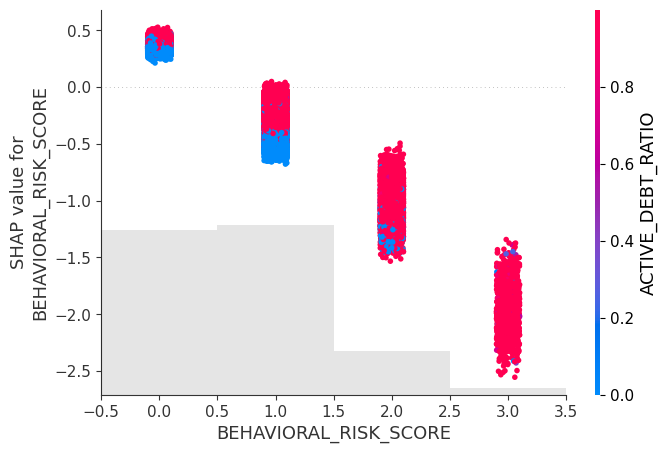

In [73]:
# ============================================================
# MODERN SHAP DEPENDENCE PLOT ⭐⭐⭐
# ============================================================

shap.plots.scatter(

    shap_values[
        :, "BEHAVIORAL_RISK_SCORE"
    ],

    color=shap_values[
        :, "ACTIVE_DEBT_RATIO"
    ]
)

In [74]:
probabilities = xgb_model.predict_proba(
    X_test_reset
)

print(probabilities[:5])

[[0.93467593 0.06532408]
 [0.91217434 0.08782567]
 [0.6714399  0.32856014]
 [0.8663208  0.13367921]
 [0.82297105 0.17702894]]


In [65]:
# customer vs customer incrementally, cleanly, enterprise-style for risky prediction
# ============================================================
# PHASE 1 — PREPARE SIMILARITY FEATURE SPACE ⭐⭐⭐
# ============================================================

from sklearn.preprocessing import StandardScaler

# ============================================================
# STEP 1 — SELECT STRONG BEHAVIORAL FEATURES
# ============================================================

similarity_features = [

    # --------------------------------------------------------
    # AFFORDABILITY
    # --------------------------------------------------------

    "DEBT_TO_INCOME",

    "CREDIT_TO_ANNUITY_RATIO",

    # --------------------------------------------------------
    # EXTERNAL TRUST
    # --------------------------------------------------------

    "EXT_SOURCE_MEAN",

    # --------------------------------------------------------
    # REPAYMENT BEHAVIOR
    # --------------------------------------------------------

    "AVG_PAYMENT_DELAY",

    "LATE_PAYMENT_COUNT",

    # --------------------------------------------------------
    # BORROWING BEHAVIOR
    # --------------------------------------------------------

    "BORROWING_ACCELERATION_RATIO",

    # --------------------------------------------------------
    # LEVERAGE
    # --------------------------------------------------------

    "ACTIVE_DEBT_RATIO",

    # --------------------------------------------------------
    # STABILITY
    # --------------------------------------------------------

    "YEARS_EMPLOYED",

    # --------------------------------------------------------
    # COMPOSITE RISK
    # --------------------------------------------------------

    "BEHAVIORAL_RISK_SCORE"
]

# ============================================================
# STEP 2 — EXTRACT TRAINING FEATURES
# ============================================================

X_similarity = X_train[
    similarity_features
].copy()

# ============================================================
# STEP 3 — SCALE FEATURES ⭐⭐⭐
# IMPORTANT:
# Distance methods REQUIRE scaling.
# ============================================================

scaler = StandardScaler()

X_similarity_scaled = scaler.fit_transform(
    X_similarity
)

# ============================================================
# STEP 4 — CONVERT BACK TO DATAFRAME
# ============================================================

X_similarity_scaled = pd.DataFrame(

    X_similarity_scaled,

    columns=similarity_features,

    index=X_similarity.index
)

# ============================================================
# STEP 5 — SPLIT DEFAULT vs SAFE CUSTOMERS
# ============================================================

default_customers = X_similarity_scaled[
    y_train == 1
]

safe_customers = X_similarity_scaled[
    y_train == 0
]

# ============================================================
# STEP 6 — VALIDATION
# ============================================================

print("\n================================================")
print("SIMILARITY DATA PREPARED")
print("================================================")

print(
    f"Scaled Training Shape: "
    f"{X_similarity_scaled.shape}"
)

print(
    f"Default Customers: "
    f"{default_customers.shape[0]}"
)

print(
    f"Safe Customers: "
    f"{safe_customers.shape[0]}"
)


SIMILARITY DATA PREPARED
Scaled Training Shape: (246008, 9)
Default Customers: 19860
Safe Customers: 226148


In [55]:
# ============================================================
# STEP 8 — SIDE-BY-SIDE COMPARISON TABLE ⭐⭐⭐
# ============================================================

comparison_df = pd.DataFrame({

    "TARGET_CUSTOMER": target_customer_features,

    "CLOSEST_DEFAULT": closest_default_customer,

    "CLOSEST_SAFE": closest_safe_customer
})

# ============================================================
# ROUND VALUES FOR READABILITY
# ============================================================

comparison_df = comparison_df.round(3)

# ============================================================
# DISPLAY DISTANCES
# ============================================================

print("\n================================================")
print("SIMILARITY DISTANCES")
print("================================================")

print(
    f"Closest Default Distance: "
    f"{closest_default_distance:.4f}"
)

print(
    f"Closest Safe Distance: "
    f"{closest_safe_distance:.4f}"
)

# ============================================================
# DISPLAY SIDE-BY-SIDE TABLE
# ============================================================

print("\n================================================")
print("CUSTOMER FEATURE COMPARISON")
print("================================================")

display(comparison_df)

# ============================================================
# INTERPRETATION
# ============================================================

print("\n================================================")
print("SIMILARITY INTERPRETATION")
print("================================================")

if closest_default_distance < closest_safe_distance:

    print(
        "Customer is MORE similar "
        "to historical defaulters."
    )

else:

    print(
        "Customer is MORE similar "
        "to historical safe customers."
    )


SIMILARITY DISTANCES
Closest Default Distance: 0.4343
Closest Safe Distance: 0.1227

CUSTOMER FEATURE COMPARISON


,TARGET_CUSTOMER,CLOSEST_DEFAULT,CLOSEST_SAFE
DEBT_TO_INCOME,1.215,0.138,-0.216
CREDIT_TO_ANNUITY_RATIO,25.109,0.521,0.347
EXT_SOURCE_MEAN,0.511,-0.182,-0.055
AVG_PAYMENT_DELAY,0.000,-0.132,-0.132
LATE_PAYMENT_COUNT,0.000,-0.514,-0.514
BORROWING_ACCELERATION_RATIO,0.200,0.704,0.704
ACTIVE_DEBT_RATIO,1.000,0.824,0.824
YEARS_EMPLOYED,0.288,-0.482,-0.480
BEHAVIORAL_RISK_SCORE,1.000,0.381,0.381



SIMILARITY INTERPRETATION
Customer is MORE similar to historical safe customers.
